In [40]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

ROOT = Path.cwd().resolve().parent
CSV_PATH = ROOT / "data" / "training" / "attendance_synthetic.csv"
MODEL_PATH = ROOT / "models" / "xgboost_attendance.ubj"

df = pd.read_csv(CSV_PATH)
print(f"Загружено {len(df)} строк")

model = xgb.XGBRegressor()
model.load_model(str(MODEL_PATH))
print("Модель загружена успешно")

Загружено 400 строк
Модель загружена успешно


In [41]:
TARGET = 'actual_attendance'
FEATURES = df.columns.drop(TARGET).tolist()

X = df[FEATURES].copy()
y = df[TARGET].copy()

cat_features = ['discipline_name', 'tournament_type']
for col in cat_features:
    if col in X.columns:
        X[col] = X[col].astype('category')

y_pred = model.predict(X)

df['predicted'] = y_pred
df['residual'] = df['actual_attendance'] - df['predicted']
df['abs_error'] = np.abs(df['residual'])

In [42]:
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print(f"MAE   : {mae:.1f} человек")
print(f"RMSE  : {rmse:.1f} человек")
print(f"R²    : {r2:.4f}")

MAE   : 76.1 человек
RMSE  : 373.8 человек
R²    : 0.8618


## 1. Самые важные признаки


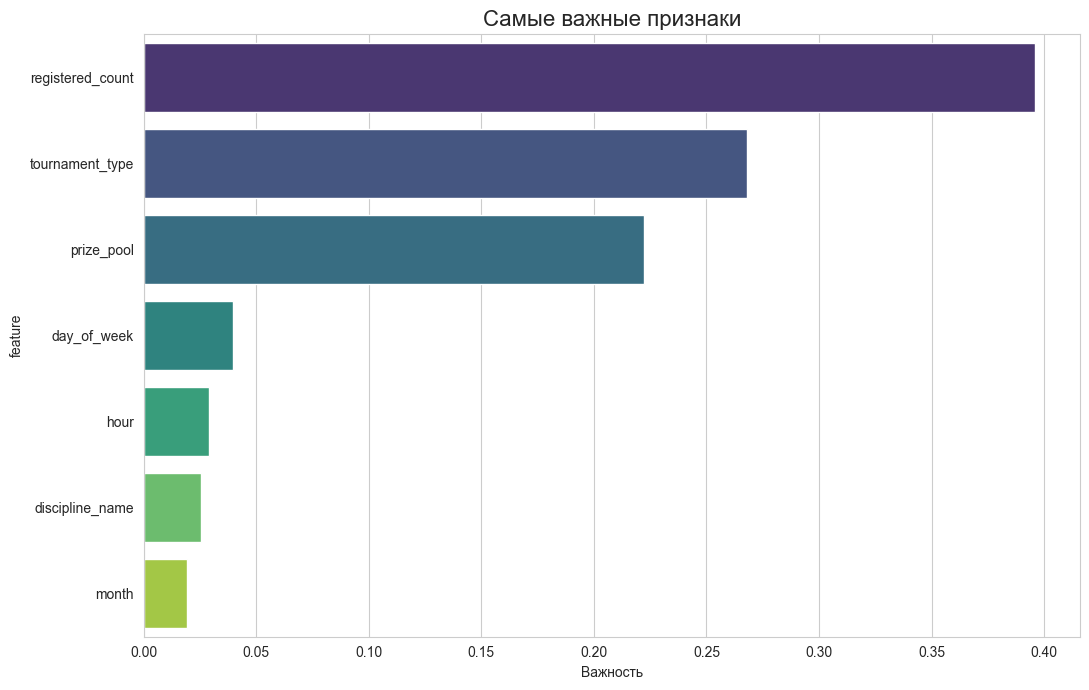


Распределение признаков:
          feature  importance
registered_count    0.396107
 tournament_type    0.268206
      prize_pool    0.222467
     day_of_week    0.039533
            hour    0.029046
 discipline_name    0.025423
           month    0.019218


In [43]:
importances = pd.DataFrame({
    'feature': model.feature_names_in_,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(11, 7))
sns.barplot(
    data=importances.head(15),
    x='importance',
    y='feature',
    hue='feature',
    palette='viridis',
    legend=False
)

plt.title('Самые важные признаки', fontsize=16)
plt.xlabel('Важность')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=200)
plt.show()

print("\nРаспределение признаков:\n", importances.head(10).to_string(index=False))

## 2. Реально vs Предсказано

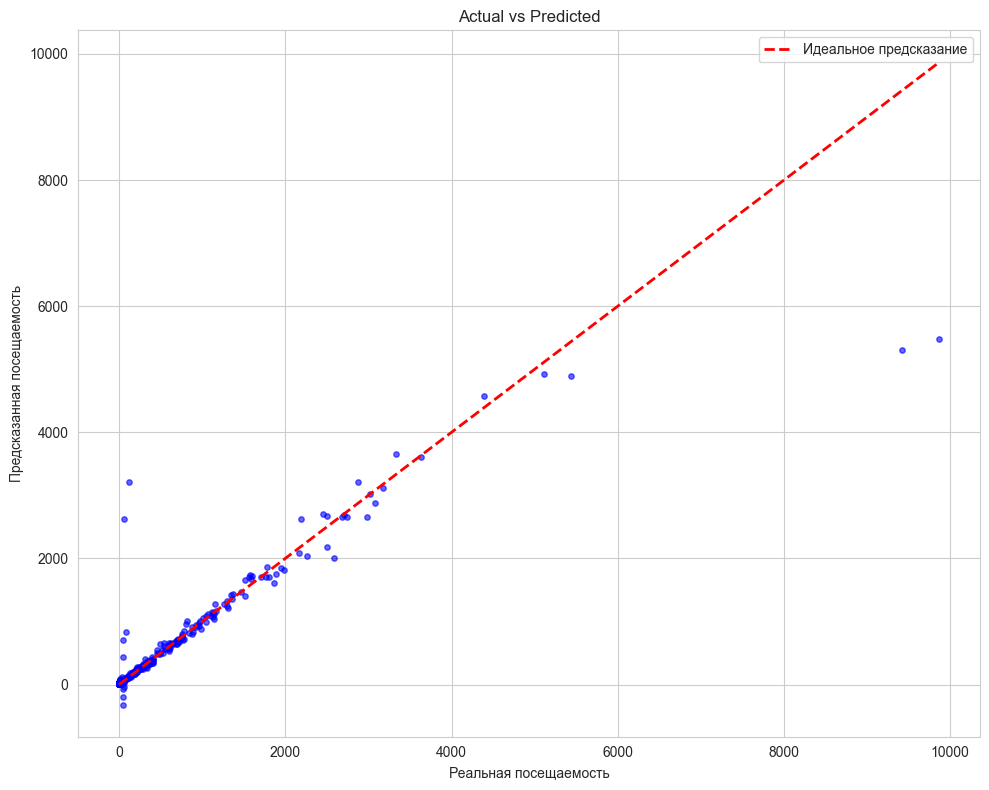

In [44]:

plt.figure(figsize=(10, 8))
plt.scatter(df['actual_attendance'], df['predicted'], alpha=0.6, s=15, color='blue')
plt.plot([0, df['actual_attendance'].max()],
         [0, df['actual_attendance'].max()], 'r--', lw=2, label='Идеальное предсказание')
plt.xlabel('Реальная посещаемость')
plt.ylabel('Предсказанная посещаемость')
plt.title('Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=200)
plt.show()

## 3. График остатков

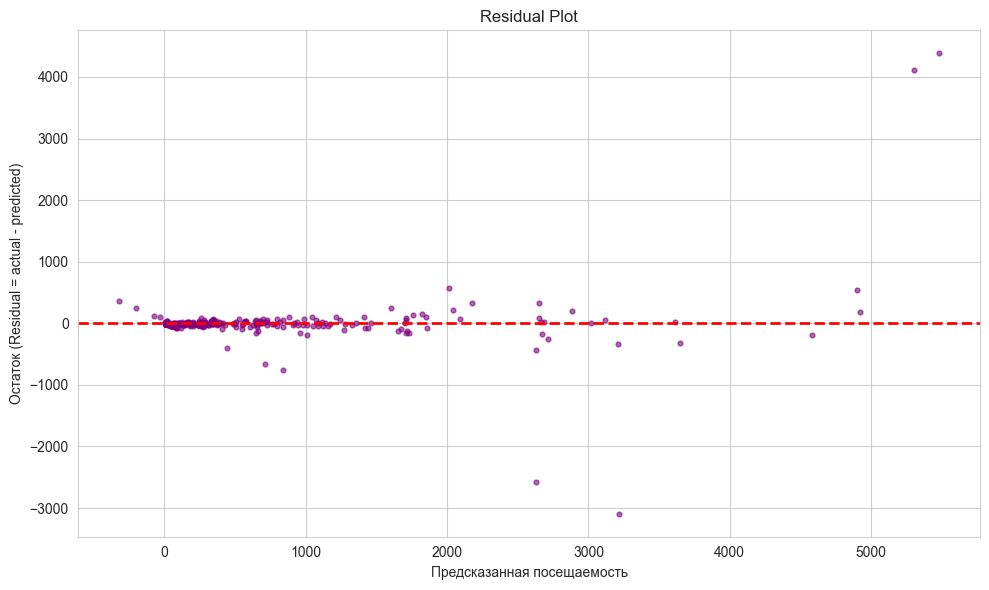

In [45]:
plt.figure(figsize=(10, 6))
plt.scatter(df['predicted'], df['residual'], alpha=0.6, s=12, color='purple')
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel('Предсказанная посещаемость')
plt.ylabel('Остаток (Residual = actual - predicted)')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

## 4. Распределение ошибок

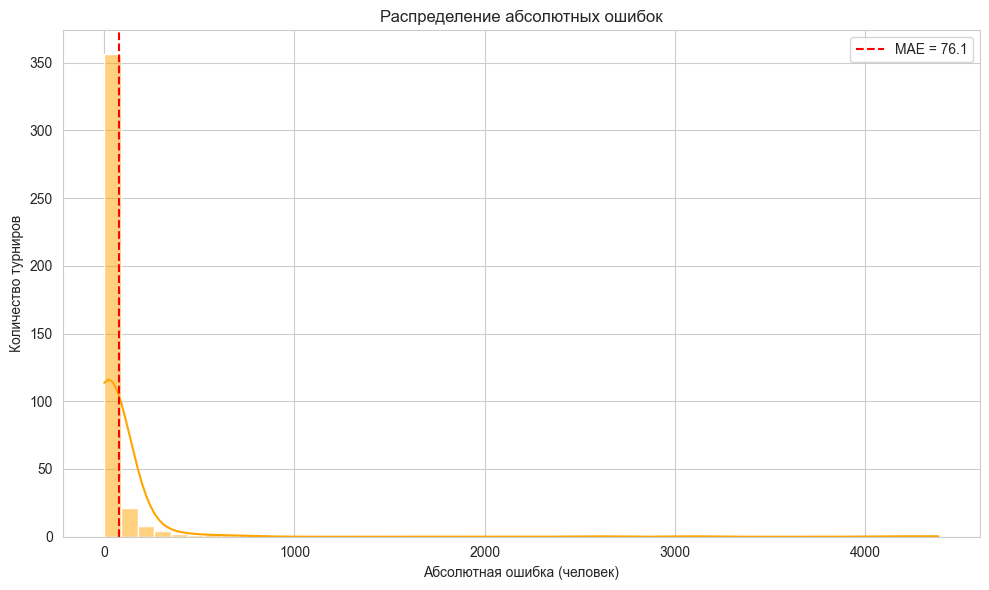

In [46]:
plt.figure(figsize=(10, 6))
sns.histplot(df['abs_error'], kde=True, bins=50, color='orange')
plt.axvline(df['abs_error'].mean(), color='red', linestyle='--', label=f'MAE = {mae:.1f}')
plt.xlabel('Абсолютная ошибка (человек)')
plt.ylabel('Количество турниров')
plt.title('Распределение абсолютных ошибок')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Ошибки по типу турнира

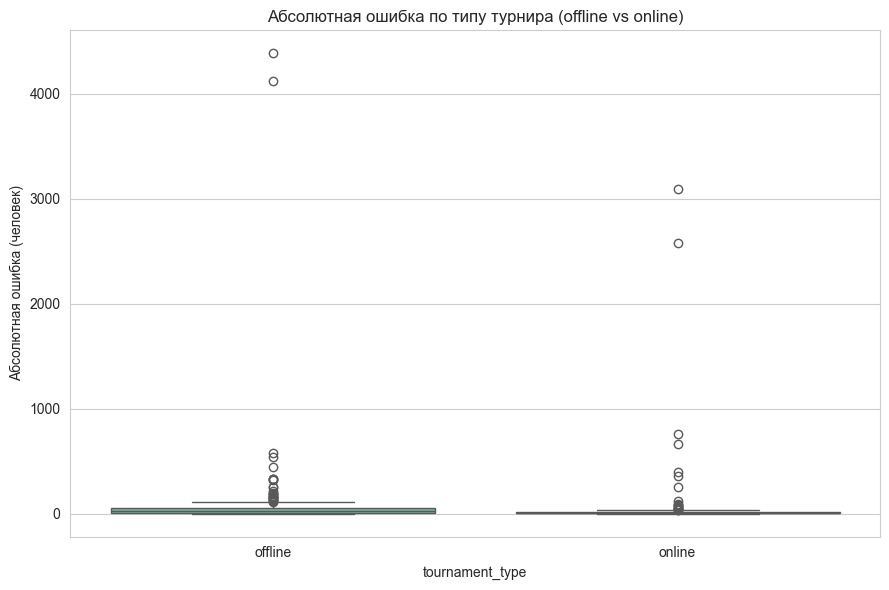


Ошибки по типу турнира:
                 mean  median     max  count
tournament_type                             
offline          85.2    24.2  4384.1    235
online           63.1     9.2  3092.5    165


In [47]:

plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x='tournament_type', y='abs_error', hue='tournament_type', palette='Set2', legend=False)
plt.title('Абсолютная ошибка по типу турнира (offline vs online)')
plt.ylabel('Абсолютная ошибка (человек)')
plt.tight_layout()
plt.show()

print("\nОшибки по типу турнира:")
print(df.groupby('tournament_type')['abs_error'].agg(['mean', 'median', 'max', 'count']).round(1))

## 6. Ошибки в зависимости от размера

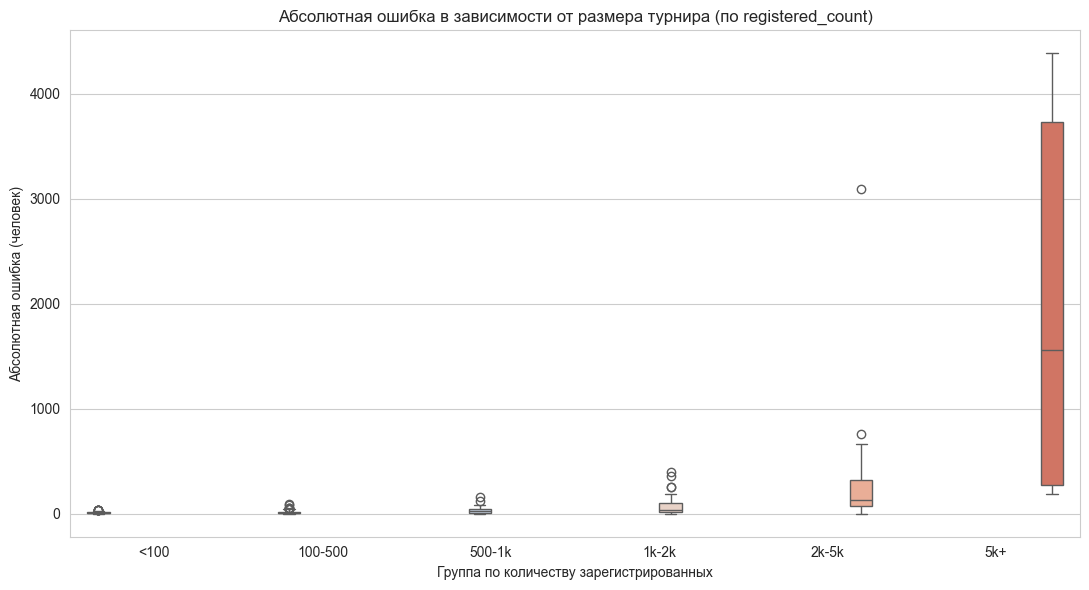


Ошибки по размеру турнира:
              mean  median  count
size_group                       
<100          12.7     8.8     68
100-500       15.2    10.3    176
500-1k        31.0    25.9     70
1k-2k         73.9    38.2     48
2k-5k        286.9   135.0     32
5k+         1999.1  1558.6      6


In [48]:
df['size_group'] = pd.cut(df['registered_count'],
                          bins=[0, 100, 500, 1000, 2000, 5000, np.inf],
                          labels=['<100', '100-500', '500-1k', '1k-2k', '2k-5k', '5k+'])

plt.figure(figsize=(11, 6))
sns.boxplot(data=df, x='size_group', y='abs_error', hue='size_group', palette='coolwarm', legend=False)
plt.title('Абсолютная ошибка в зависимости от размера турнира (по registered_count)')
plt.xlabel('Группа по количеству зарегистрированных')
plt.ylabel('Абсолютная ошибка (человек)')
plt.tight_layout()
plt.show()

print("\nОшибки по размеру турнира:")
print(df.groupby('size_group')['abs_error'].agg(['mean', 'median', 'count']).round(1))